## PCK1 and SOX4 / SOX9 - atlasv2

In [20]:
import gc
import json
import re
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.stats import sem, ttest_ind, ttest_rel, wilcoxon

In [21]:
# inputs and config

# directory
COHORT_DIR = Path("cohort")
LABEL_SETS_PATH = COHORT_DIR / "label_sets.json"

# outputs
RESULTS_DIR     = Path("results")
FIGURE_DIR      = RESULTS_DIR / "figures"
TABLE_DIR       = RESULTS_DIR / "tables"
SOURCE_DATA_DIR = RESULTS_DIR / "source_data"
OBJECT_DIR      = RESULTS_DIR / "objects"

for directory in [COHORT_DIR, FIGURE_DIR, TABLE_DIR, SOURCE_DATA_DIR, OBJECT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# config
COUNTS_LAYER = "counts"          # raw integer counts; None falls back to .X
CELLTYPE_COL = "v2.subclass.l2"  # annotation column in each object
GENES = ["SOX4", "PCK1", "SOX9"]
POS_THRESHOLD = 2                # positive if raw count > this, i.e. 3+
COL_SAMPLE = "Sample_ID"

# cycPT is excluded from both PT states by default; "healthy" or "altered" fold it in
CYCPT_GROUP = "exclude"

# cohort already filtered at min_counts=20 upstream, so no further total-count filter is applied here
# set a number to re-filter
MIN_TOTAL_COUNTS = None

# internal contrast
REF_LABEL = "Ref"
CKD_LABEL = "CKD"

# diagnosis
PRIMARY_CONTRAST = {"HRT": REF_LABEL, "DKD": CKD_LABEL, "H-CKD": CKD_LABEL}

# expected cohort composition
EXPECTED = {
    "n_samples": 37,
    "full":      {REF_LABEL: 9, CKD_LABEL: 28},
    "main_only": {REF_LABEL: 6, CKD_LABEL: 27},
}

# whether to save combined per-cell table (large); off by default
WRITE_CELL_TABLE = True

# populated at load
SAMPLE_DX = {}        # sample_id -> diagnosis
SAMPLE_SITE = {}      # sample_id -> site
SAMPLE_CATEGORY = {}  # sample_id -> REF_LABEL / CKD_LABEL / None; set by set_contrast

HEALTHY_PT_LABELS = set()
ALTERED_PT_LABELS = set()
CYCPT_LABELS = set()
TUBULAR_EPI_LABELS = set()

In [22]:
# per cell extraction 

def extract_cell_table(adata, sample_id):
    """One row per cell: sample, cell type, total counts, and per-gene count + positivity."""
    name_to_idx = {name: i for i, name in enumerate(adata.var_names)}

    missing = [g for g in GENES if g not in name_to_idx]
    if missing:
        raise ValueError(f"{sample_id}: gene(s) not found in var_names: {missing}")

    gene_cols = [name_to_idx[g] for g in GENES]
    matrix = adata.layers[COUNTS_LAYER] if COUNTS_LAYER is not None else adata.X

    total_per_cell = np.asarray(matrix.sum(axis=1)).ravel()

    counts = (
        np.asarray(matrix[:, gene_cols].todense()) if sp.issparse(matrix)
        else np.asarray(matrix)[:, gene_cols]
    ).astype(float)

    # Guard against a normalized matrix being passed off as counts.
    finite = counts[np.isfinite(counts)]
    if finite.size and (finite.min() < 0 or not np.allclose(finite, np.round(finite))):
        raise ValueError(f"{sample_id}: layer '{COUNTS_LAYER}' is not raw integer counts.")

    if CELLTYPE_COL not in adata.obs.columns:
        raise ValueError(
            f"{sample_id}: no .obs column '{CELLTYPE_COL}'. Has {list(adata.obs.columns)}"
        )

    table = pd.DataFrame({
        COL_SAMPLE: sample_id,
        "cell_type": adata.obs[CELLTYPE_COL].astype(str).to_numpy(),
        "total_count": total_per_cell,
    })

    for j, gene in enumerate(GENES):
        table[f"{gene}_count"] = counts[:, j]
        table[f"{gene}_pos"] = table[f"{gene}_count"] > POS_THRESHOLD

    return table


def per_sample_summary(df, mask, gene, state_label):
    """Collapse cells to one row per sample: eligible, positive, and percent positive."""
    out = (
        df.loc[mask]
        .groupby(COL_SAMPLE)[f"{gene}_pos"]
        .agg(eligible_cells="size", positive_cells="sum")
        .reset_index()
    )

    out["percent_positive"] = 100.0 * out["positive_cells"] / out["eligible_cells"]
    out["gene"] = gene
    out["PT_state"] = state_label
    out["Category"] = out[COL_SAMPLE].map(SAMPLE_CATEGORY)

    return out

In [23]:
# file locations
DX_XLSX = Path(
    "/storage2/fs1/sanjayjain/Active/Xenium/Data/KPMP/ANALYSIS/kpmp_dx.xlsx"
)
MAIN_DIR = Path(
    "/storage2/fs1/sanjayjain/Active/Xenium/Data/KPMP/ANALYSIS/full_objects"
)
TISAC_DIR = Path(
    "/storage2/fs1/sanjayjain/Active/Xenium/ATLASV2_REBUTTAL/data/480_TISAC/"
    "ATLASV2_480_TISAC_MINCOUNTS20_ANALYSIS_allgenes_taccofix/full_objects"
)

# columns in the diagnosis spreadsheet
PPID_COL = "PPID"
DX_COL = "Dx"

# samples
MAIN_SAMPLES = [
    "xen37_28-12510",
    "xen37_29-10395",
    "xen37_31-10105",
    "xen37_31-10236",
    "xen38_164-17",
    "xen38_31-10100",
    "xen41_164-21",
    "xen41_29-10010",
    "xen41_29-10404",
    "xen41_935-10542",
    "xen42_27-10154",
    "xen42_28-10051",
    "xen42_936-10948",
    "xen47_31-10000",
    "xen48_27-10042",
    "xen48_28-12263",
    "xen48_29-10277",
    "xen49_164-1",
    "xen50_164-5",
    "xen51_29-10011",
    "xen51_31-10001",
    "xen51_31-10035",
    "xen53_29-11429",
    "xen53_31-10864",
    "xen53_31-11370",
    "xen53_933-11034",
    "xen53_934-10141",
    "xen54_164-7",
    "xen54B_29-11453",
    "xen55_935-10530",
    "xen55_936-10746",
    "xen56_164-3",
    "xen59B_936-10110",
]

# addtl available samples (same gene panel and correct dx only)
EXTERNAL_SAMPLES = {
    "TISAC_hrt_1": "/storage2/fs1/sanjayjain/Active/Xenium/ATLASV2_REBUTTAL/ATLASV2_480SAMPLES_MINCOUNTS20_ANALYSIS_allgenes_taccofix/full_objects/xen31_3781_annotated_480SAMPLES_mincounts20_allgenes_taccofix.h5ad",
    "TISAC_ckd_1": "/storage2/fs1/sanjayjain/Active/Xenium/ATLASV2_REBUTTAL/ATLASV2_480SAMPLES_MINCOUNTS20_ANALYSIS_allgenes_taccofix/full_objects/xen31_3990_annotated_480SAMPLES_mincounts20_allgenes_taccofix.h5ad",
    "TISAC_hrt_2": "/storage2/fs1/sanjayjain/Active/Xenium/ATLASV2_REBUTTAL/ATLASV2_480SAMPLES_MINCOUNTS20_ANALYSIS_allgenes_taccofix/full_objects/xen31_KPMP038_annotated_480SAMPLES_mincounts20_allgenes_taccofix.h5ad",
    "TISAC_hrt_3": "/storage2/fs1/sanjayjain/Active/Xenium/ATLASV2_REBUTTAL/ATLASV2_480SAMPLES_MINCOUNTS20_ANALYSIS_allgenes_taccofix/full_objects/xen32_KPMP101_annotated_480SAMPLES_mincounts20_allgenes_taccofix.h5ad",
}



# diagnoses for samples the spreadsheet does not cover (addtl samples)
EXTRA_DX = {
    "TISAC_hrt_1": "HRT",
    "TISAC_ckd_1": "H-CKD",
    "TISAC_hrt_2": "HRT",
    "TISAC_hrt_3": "HRT",
}

In [24]:
# functions

def resolve_main_file(sample_id, directory=None):
    """
    Find the object for a main-site sample by prefix. Exactly one file must match,
    so a renamed or duplicated object surfaces here rather than being picked
    arbitrarily.
    """
    directory = MAIN_DIR if directory is None else Path(directory)
    matches = sorted(directory.glob(f"{sample_id}*.h5ad"))

    if len(matches) == 1:
        return matches[0].name

    if not matches:
        raise FileNotFoundError(f"{sample_id}: no object matching {sample_id}*.h5ad in {directory}")

    raise ValueError(
        f"{sample_id}: {len(matches)} objects match {sample_id}*.h5ad — "
        f"{[m.name for m in matches]}. Name the intended file explicitly."
    )


def build_manifest(main_samples=None, external_samples=None,
                   dx_xlsx=DX_XLSX, extra_dx=None):
    """
    Resolve every sample to a file path and attach a diagnosis.

    Diagnosis comes from the spreadsheet, matched on the PPID parsed out of the
    sample id ('xen51_29-10011' -> '29-10011'). Samples the spreadsheet does not
    cover fall back to extra_dx. Anything still without a diagnosis raises — a
    sample must never reach the analysis with an unknown group.
    """
    main_samples = MAIN_SAMPLES if main_samples is None else main_samples
    external_samples = EXTERNAL_SAMPLES if external_samples is None else external_samples
    extra_dx = EXTRA_DX if extra_dx is None else extra_dx

    rows = []

    for sample_id in main_samples:
        run, _, ppid = sample_id.partition("_")
        rows.append({
            "sample_id": sample_id, "site": "main", "run": run, "ppid": ppid,
            "filename": resolve_main_file(sample_id), "directory": str(MAIN_DIR),
        })

    for sample_id, filename in external_samples.items():
        rows.append({
            "sample_id": sample_id, "site": "TISAC",
            "run": sample_id.partition("_")[0], "ppid": pd.NA,
            "filename": filename, "directory": str(TISAC_DIR),
        })

    manifest = pd.DataFrame(rows)

    if manifest["sample_id"].duplicated().any():
        dupes = sorted(manifest.loc[manifest["sample_id"].duplicated(), "sample_id"])
        raise ValueError(f"Duplicate sample_id: {dupes}")

    # One section per participant is the stated inclusion rule, so a repeated PPID
    # would mean the de-duplication was not applied.
    main_ppids = manifest.loc[manifest["site"] == "main", "ppid"]
    if main_ppids.duplicated().any():
        dupes = sorted(main_ppids[main_ppids.duplicated()])
        raise ValueError(f"Repeated PPID in the main-site list: {dupes}")

    manifest["path"] = [
        str(Path(d) / f) for d, f in zip(manifest["directory"], manifest["filename"])
    ]

    missing = [p for p in manifest["path"] if not Path(p).exists()]
    if missing:
        for p in missing[:10]:
            print(f"  MISSING  {p}")
        raise FileNotFoundError(f"{len(missing)} of {len(manifest)} objects not found.")

    # --- join diagnosis from the spreadsheet ---------------------------------
    meta = pd.read_excel(dx_xlsx)

    for col in (PPID_COL, DX_COL):
        if col not in meta.columns:
            raise ValueError(f"{dx_xlsx.name} missing column {col!r}; has {list(meta.columns)}")

    def norm(s):
        return str(s).strip().lower()

    dx_by_ppid = (
        meta.assign(_pp=meta[PPID_COL].map(norm))
        .drop_duplicates("_pp")
        .set_index("_pp")[DX_COL]
    )

    manifest["dx"] = manifest["ppid"].map(lambda p: dx_by_ppid.get(norm(p)) if pd.notna(p) else None)
    manifest["dx_source"] = np.where(manifest["dx"].notna(), dx_xlsx.name, pd.NA)

    # --- fall back for samples the spreadsheet does not cover ----------------
    fallback = manifest["dx"].isna() & manifest["sample_id"].isin(extra_dx)
    manifest.loc[fallback, "dx"] = manifest.loc[fallback, "sample_id"].map(extra_dx)
    manifest.loc[fallback, "dx_source"] = "EXTRA_DX (not a KPMP participant)"

    still_missing = manifest.loc[manifest["dx"].isna(), ["sample_id", "ppid"]]
    if len(still_missing):
        print(still_missing.to_string(index=False))
        raise ValueError(
            f"{len(still_missing)} sample(s) have no diagnosis. Add them to "
            f"{dx_xlsx.name} or to EXTRA_DX."
        )

    manifest["group"] = (
        manifest["dx"].map({"HRT": "HRT", "DKD": "CKD", "H-CKD": "CKD"}).fillna("other")
    )

    return manifest[["sample_id", "site", "run", "ppid", "dx", "group",
                     "dx_source", "filename", "path"]]


manifest = build_manifest()

print(f"Cohort: {len(manifest)} samples "
      f"({(manifest['site'] == 'main').sum()} main + "
      f"{(manifest['site'] != 'main').sum()} external)")

print("\nDiagnosis source:")
print(manifest["dx_source"].value_counts().to_string())

print("\nBy site and diagnosis:")
print(manifest.groupby(["site", "dx"]).size().to_string())

print(f"\nXenium runs represented: {manifest['run'].nunique()}")

if len(manifest) != EXPECTED["n_samples"]:
    raise ValueError(f"Expected {EXPECTED['n_samples']} samples, resolved {len(manifest)}.")

manifest.drop(columns=["path"]).to_csv(COHORT_DIR / "cohort_resolved.csv", index=False)
print(f"\nWrote {COHORT_DIR / 'cohort_resolved.csv'}")

Cohort: 37 samples (33 main + 4 external)

Diagnosis source:
dx_source
kpmp_dx.xlsx                         33
EXTRA_DX (not a KPMP participant)     4

By site and diagnosis:
site   dx   
TISAC  H-CKD     1
       HRT       3
main   DKD      19
       H-CKD     8
       HRT       6

Xenium runs represented: 16

Wrote cohort/cohort_resolved.csv


In [25]:
# load objs

CELL_COUNTS_PATH = COHORT_DIR / "cell_counts.csv"


def load_cohort(manifest, min_total_counts=MIN_TOTAL_COUNTS):
    """Load every sample in the manifest and return the combined per-cell table."""
    global SAMPLE_DX, SAMPLE_SITE

    tables, dx_map, site_map, floors, counts = [], {}, {}, {}, {}

    for row in manifest.itertuples():
        adata = ad.read_h5ad(row.path)
        table = extract_cell_table(adata, row.sample_id)

        counts[row.sample_id] = len(table)
        floors[row.sample_id] = float(table["total_count"].min())
        dx_map[row.sample_id] = row.dx
        site_map[row.sample_id] = row.site
        tables.append(table)

        print(f"  {row.sample_id:<24} {len(table):>8,} cells  floor={floors[row.sample_id]:g}  "
              f"dx={row.dx}  site={row.site}")

        del adata
        gc.collect()

    # Pin cell counts on first run; compare thereafter.
    observed = pd.Series(counts, name="n_cells").sort_index()

    if CELL_COUNTS_PATH.exists():
        pinned = pd.read_csv(CELL_COUNTS_PATH, index_col=0)["n_cells"].sort_index()
        combined = pd.concat([pinned.rename("pinned"), observed.rename("loaded")], axis=1)
        drift = combined[combined["pinned"] != combined["loaded"]]

        if len(drift):
            print("\n" + drift.to_string())
            raise ValueError(
                f"Cell counts differ from {CELL_COUNTS_PATH}. The objects on disk "
                "changed since the cohort was pinned; results would not match the "
                "published analysis."
            )
        print(f"\nCell counts match {CELL_COUNTS_PATH}")
    else:
        observed.to_frame().to_csv(CELL_COUNTS_PATH)
        print(f"\nPinned cell counts to {CELL_COUNTS_PATH} — commit this file.")

    df = pd.concat(tables, ignore_index=True)
    SAMPLE_DX, SAMPLE_SITE = dx_map, site_map

    if min_total_counts is not None:
        before = len(df)
        df = df[df["total_count"] >= min_total_counts].copy()
        print(f"Harmonized to min_total_counts={min_total_counts}: {before:,} -> {len(df):,} cells")

    print(f"Loaded {len(manifest)} samples, {len(df):,} cells.")
    print(f"Distinct per-sample count floors: {sorted(set(floors.values()))}")

    return df


df = load_cohort(manifest)

  xen37_28-12510              7,612 cells  floor=20  dx=H-CKD  site=main
  xen37_29-10395             30,072 cells  floor=20  dx=DKD  site=main
  xen37_31-10105             42,316 cells  floor=20  dx=DKD  site=main
  xen37_31-10236             58,015 cells  floor=20  dx=DKD  site=main
  xen38_164-17                8,295 cells  floor=20  dx=HRT  site=main
  xen38_31-10100             31,633 cells  floor=20  dx=DKD  site=main
  xen41_164-21               30,194 cells  floor=20  dx=HRT  site=main
  xen41_29-10010             42,942 cells  floor=20  dx=DKD  site=main
  xen41_29-10404             56,196 cells  floor=20  dx=DKD  site=main
  xen41_935-10542            21,431 cells  floor=20  dx=DKD  site=main
  xen42_27-10154             14,447 cells  floor=20  dx=DKD  site=main
  xen42_28-10051             10,017 cells  floor=20  dx=DKD  site=main
  xen42_936-10948            70,115 cells  floor=20  dx=DKD  site=main
  xen47_31-10000              8,166 cells  floor=20  dx=H-CKD  site=main
  

In [26]:
# cell type label sets

def derive_kidney_label_sets(labels, verbose=True):
    """Split the annotation vocabulary into healthy PT, altered PT, cycPT and tubular epi."""
    labels = sorted({str(l) for l in labels})
    upper = {l: l.upper() for l in labels}

    healthy_pt = {l for l in labels if re.match(r"PT-S\d", l, re.I)}

    altered_pt = {
        l for l in labels
        if re.search(r"PT$", l, re.I)
        and not re.match(r"PT-S\d", l, re.I)
        and "CYC" not in upper[l]
        and "EC" not in upper[l]
    }

    cyc_pt = {l for l in labels if upper[l] == "CYCPT"}

    def excluded(l):
        u = upper[l]
        if "EC" in u or "POD" in u:
            return True
        if u in {"MC", "REN", "SC/NEU", "NEU"}:
            return True
        return any(k in u for k in ("FIB", "VSMC", "MYOF", "SMC", "PERI"))

    tubular_re = re.compile(r"(PT-S\d|PT$|TAL|ATL|DTL|DCT|CNT|PC$|IMCD|IC-|IC$|^MD$)", re.I)
    tubular = {l for l in labels if tubular_re.search(l) and not excluded(l)}

    leftover = [l for l in labels if l not in (healthy_pt | altered_pt | cyc_pt | tubular)]

    if verbose:
        print("HEALTHY_PT_LABELS  =", sorted(healthy_pt))
        print("ALTERED_PT_LABELS  =", sorted(altered_pt))
        print("CYCPT_LABELS       =", sorted(cyc_pt))
        print("TUBULAR_EPI_LABELS =", sorted(tubular))
        print("\nNOT classified as PT/tubular (eyeball):", sorted(leftover))

    return {
        "healthy_pt": sorted(healthy_pt),
        "altered_pt": sorted(altered_pt),
        "cyc_pt": sorted(cyc_pt),
        "tubular": sorted(tubular),
        "unclassified": sorted(leftover),
    }


sets = derive_kidney_label_sets(df["cell_type"].unique())

if LABEL_SETS_PATH.exists():
    pinned = json.loads(LABEL_SETS_PATH.read_text())
    drift = {k: (pinned.get(k), sets.get(k)) for k in ("healthy_pt", "altered_pt", "cyc_pt", "tubular")
             if pinned.get(k) != sets.get(k)}

    if drift:
        for key, (was, now) in drift.items():
            print(f"  [FAIL] {key}\n      pinned: {was}\n      now:    {now}")
        raise ValueError(
            f"Derived label sets differ from {LABEL_SETS_PATH}. The annotation "
            "vocabulary changed upstream; resolve before trusting these results."
        )
    print(f"\nLabel sets match {LABEL_SETS_PATH}")
else:
    LABEL_SETS_PATH.write_text(json.dumps(sets, indent=2))
    print(f"\nPinned label sets to {LABEL_SETS_PATH} — commit this file.")

HEALTHY_PT_LABELS  = set(sets["healthy_pt"])
ALTERED_PT_LABELS  = set(sets["altered_pt"])
CYCPT_LABELS       = set(sets["cyc_pt"])
TUBULAR_EPI_LABELS = set(sets["tubular"])

HEALTHY_PT_LABELS  = ['PT-S1', 'PT-S2', 'PT-S3']
ALTERED_PT_LABELS  = ['aPT', 'dPT', 'frPT']
CYCPT_LABELS       = ['cycPT']
TUBULAR_EPI_LABELS = ['ATL', 'C-IC-A', 'C-PC', 'C-TAL', 'C/M-TAL', 'CNT', 'DCT', 'DTL1', 'DTL2', 'DTL3', 'IC-B', 'IMCD', 'M-IC-A', 'M-PC', 'M-TAL', 'MD', 'PT-S1', 'PT-S2', 'PT-S3', 'aCNT', 'aDCT', 'aDTL', 'aPT', 'aTAL', 'cycPT', 'cycTAL', 'dATL', 'dC-IC-A', 'dC-TAL', 'dCNT', 'dDCT', 'dDTL', 'dIMCD', 'dM-IC-A', 'dM-PC', 'dM-TAL', 'dPT', 'frPT', 'frTAL', 'tPC-IC']

NOT classified as PT/tubular (eyeball): ['B', 'DC', 'EC-AA', 'EC-AVR', 'EC-DVR', 'EC-EA', 'EC-GC', 'EC-LYM', 'EC-PCV', 'EC-PTC', 'EC-V', 'ERY', 'FIB', 'M-FIB', 'MAST', 'MC', 'MON', 'MYOF', 'N', 'NEU', 'NK', 'PEC', 'PL', 'POD', 'REN', 'SC/NEU', 'T', 'VSMC', 'VSMC/P', 'aEC-GC', 'angEC-PTC', 'cycEC', 'cycMAC', 'cycT', 'dEC-AVR', 'dEC-GC', 'dEC-PTC', 'dFIB', 'dM-FIB', 'dPOD', 'dVSMC', 'infEC-AVR', 'infEC-PTC', 'infFIB', 'moMAC', 'moMAC-INF', 'pvFIB', 'resMAC']

Label sets match cohort/label_sets.json


In [27]:
# defining the contrast

def set_contrast(dx_to_category):
    """Map diagnosis -> REF_LABEL / CKD_LABEL. Unmapped diagnoses become None."""
    global SAMPLE_CATEGORY
    SAMPLE_CATEGORY = {s: dx_to_category.get(str(dx)) for s, dx in SAMPLE_DX.items()}

    used = pd.Series(SAMPLE_CATEGORY).dropna().value_counts().to_dict()
    print(f"Contrast set: {used}  (samples with other dx are ignored by HRT-vs-CKD tests)")


def contrast_subset(df):
    """Drop cells from samples with no contrast assignment."""
    keep = df[COL_SAMPLE].map(SAMPLE_CATEGORY).notna()
    sub = df[keep].copy()

    used = pd.Series(SAMPLE_CATEGORY).dropna().value_counts().to_dict()
    dropped = df[COL_SAMPLE].nunique() - sub[COL_SAMPLE].nunique()
    print(f"Contrast subset: {sub[COL_SAMPLE].nunique()} samples kept {used}; {dropped} unmapped dropped.")

    return sub


def check_contrast(expected, label):
    """Assert the arms have the expected sample counts."""
    got = pd.Series(SAMPLE_CATEGORY).dropna().value_counts().to_dict()
    if got != expected:
        raise ValueError(f"{label}: expected {expected}, got {got}")
    print(f"{label}: composition matches expectation {expected}")


set_contrast(PRIMARY_CONTRAST)
check_contrast(EXPECTED["full"], "Full cohort (both sites)")

Contrast set: {'CKD': 28, 'Ref': 9}  (samples with other dx are ignored by HRT-vs-CKD tests)
Full cohort (both sites): composition matches expectation {'Ref': 9, 'CKD': 28}


In [28]:
JITTER_SEED = 0


def _ref_ckd(summary, metric):
    return (summary.loc[summary["Category"] == REF_LABEL, metric].to_numpy(),
            summary.loc[summary["Category"] == CKD_LABEL, metric].to_numpy())


def _welch(ref, ckd, label):
    if len(ref) < 2 or len(ckd) < 2:
        print(f"    {label}: not enough samples (HRT n={len(ref)}, CKD n={len(ckd)})")
        return float("nan")

    _, p = ttest_ind(ref, ckd, equal_var=False, nan_policy="omit")
    print(f"    {label}:  HRT n={len(ref)} mean={np.nanmean(ref):.3f}   "
          f"CKD n={len(ckd)} mean={np.nanmean(ckd):.3f}   Welch p = {p:.4g}")
    return p


def _pct_positive(df, mask, poscol):
    g = df.loc[mask].groupby(COL_SAMPLE)[poscol].agg(elig="size", pos="sum")
    g["pct"] = 100.0 * g["pos"] / g["elig"]
    g["Category"] = [SAMPLE_CATEGORY.get(x) for x in g.index]
    return g


def dot_box_plot(vals1, vals2, labels, ylabel, title, save_path,
                 scale=1.0, paired=False, dpi=300):
    """Two-group box plot with jittered per-sample points and a significance bracket."""
    v1 = np.asarray(vals1, dtype=float) / scale
    v2 = np.asarray(vals2, dtype=float) / scale

    _, pval = (ttest_rel(v1, v2, nan_policy="omit") if paired
               else ttest_ind(v1, v2, equal_var=False, nan_policy="omit"))
    test_name = "paired t" if paired else "Welch"

    fig, ax = plt.subplots(figsize=(3, 6))
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

    ax.boxplot([v1, v2], widths=0.2, showfliers=False, patch_artist=True,
               boxprops=dict(facecolor="white", edgecolor="black"),
               medianprops=dict(color="black"))

    # The two groups have different sizes (9 vs 28), so each needs its own length.
    rng = np.random.default_rng(JITTER_SEED)
    ax.scatter(1 + rng.uniform(-0.04, 0.04, len(v1)), v1,
               color="black", s=30, alpha=0.6, edgecolors="white", linewidths=0.4, zorder=3)
    ax.scatter(2 + rng.uniform(-0.04, 0.04, len(v2)), v2,
               color="black", s=30, alpha=0.6, edgecolors="white", linewidths=0.4, zorder=3)

    everything = np.concatenate([v1, v2])
    hi, lo = np.nanmax(everything), np.nanmin(everything)
    h = (hi - lo) * 0.06 if hi > lo else max(hi * 0.06, 1.0)
    y = hi + h

    ax.plot([1, 1, 2, 2], [y, y + h, y + h, y], lw=1.3, color="black")
    ax.text(1.5, y + h * 1.1, f"{test_name} p = {pval:.2g}",
            ha="center", va="bottom", fontsize=11, style="italic")

    ax.set_xticks([1, 2])
    ax.set_xticklabels([f"{labels[0]}\n(n={len(v1)})", f"{labels[1]}\n(n={len(v2)})"],
                       fontweight="bold")
    ax.set_ylabel(ylabel, fontweight="bold")
    ax.set_title(title, fontweight="bold")
    ax.set_ylim(bottom=min(0, lo))

    plt.tight_layout()
    fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()

    print(f"Saved {save_path}")
    print(f"  {labels[0]}: n={len(v1)}, mean={np.nanmean(v1):.2f}, SEM={sem(v1, nan_policy='omit'):.2f}")
    print(f"  {labels[1]}: n={len(v2)}, mean={np.nanmean(v2):.2f}, SEM={sem(v2, nan_policy='omit'):.2f}")
    print(f"  {test_name}-test: p = {pval:.4g}")

    return pval


def _grouped_bar(results, save_path, dpi=300, figsize=(3.7, 5.8),
                 title="SOX4+/SOX9+ PT Cells", xtick_labels=None,
                 title_fontsize=15, axis_label_fontsize=14,
                 tick_fontsize=13, p_fontsize=12, legend_fontsize=12):
    """Grouped bars (HRT vs CKD) across endpoints, with per-sample dots and brackets."""
    names = list(results.keys())
    g0 = results[names[0]][0]
    n_ref = int((g0["Category"] == REF_LABEL).sum())
    n_ckd = int((g0["Category"] == CKD_LABEL).sum())

    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(names))
    width = 0.38
    rng = np.random.default_rng(JITTER_SEED)

    for cat, offset, color, lab in [
        (REF_LABEL, -width / 2, "white", f"HRT (n={n_ref})"),
        (CKD_LABEL, width / 2, "0.6", f"CKD (n={n_ckd})"),
    ]:
        means, errs, dots = [], [], []
        for name in names:
            g = results[name][0]
            v = g.loc[g["Category"] == cat, "pct"].to_numpy()
            means.append(np.nanmean(v))
            errs.append(sem(v, nan_policy="omit"))
            dots.append(v)

        ax.bar(x + offset, means, width, yerr=errs, capsize=3,
               color=color, edgecolor="black", label=lab)

        for xi, v in zip(x + offset, dots):
            ax.scatter(xi + rng.uniform(-0.06, 0.06, len(v)), v, color="black", s=11, zorder=3)

    # One bracket height for all groups: in a narrow panel, per-bar brackets
    # collide with the neighbouring group's points.
    span = max(np.nanmax(results[n][0]["pct"].to_numpy()) for n in names)
    y = span * 1.06
    h = span * 0.030

    for i, name in enumerate(names):
        p = results[name][1]
        ax.plot([x[i] - width / 2, x[i] - width / 2, x[i] + width / 2, x[i] + width / 2],
                [y, y + h, y + h, y], lw=1.1, color="black")
        ptxt = f"{p:.0e}".replace("e-0", "e-")
        ax.text(x[i], y + h * 1.35, f"p={ptxt}", ha="center", va="bottom",
                fontsize=p_fontsize, style="italic")

    ax.set_xticks(x)
    ax.set_xticklabels(xtick_labels or names, fontsize=tick_fontsize)
    ax.tick_params(axis="y", labelsize=tick_fontsize)
    ax.set_ylabel("% PT Cells", fontweight="bold", fontsize=axis_label_fontsize)
    ax.set_title(title, fontweight="bold", fontsize=title_fontsize, pad=32)
    ax.set_ylim(0, span * 1.30)

    ax.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, 1.005),
              ncol=2, fontsize=legend_fontsize, handlelength=1.1,
              columnspacing=0.9, handletextpad=0.4)

    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    print(f"Saved {save_path}")

In [29]:
def reproduce_pt_figure(df, pt_labels=None, make_plot=True, save_path=None):
    """Q0 (main figure): SOX4+, SOX9+ and double-positive PT cells, HRT vs CKD."""
    print("\n=== Q0: PT positivity, HRT vs CKD, per-sample test (SOX4 / SOX9 / double+) ===")

    if pt_labels is None:
        pt_labels = set(HEALTHY_PT_LABELS) | set(ALTERED_PT_LABELS)

    mask = df["cell_type"].isin(pt_labels)
    print(f"  PT cells: {int(mask.sum()):,}")

    df = df.copy()
    df["SOX4&SOX9_pos"] = (df["SOX4_count"] > POS_THRESHOLD) & (df["SOX9_count"] > POS_THRESHOLD)

    results, rows = {}, []
    for name, col in [("SOX4", "SOX4_pos"), ("SOX9", "SOX9_pos"), ("SOX4&SOX9", "SOX4&SOX9_pos")]:
        g = _pct_positive(df, mask, col)
        ref = g.loc[g["Category"] == REF_LABEL, "pct"].to_numpy()
        ckd = g.loc[g["Category"] == CKD_LABEL, "pct"].to_numpy()

        _, p = ttest_ind(ref, ckd, equal_var=False, nan_policy="omit")
        results[name] = (g, p)

        print(f"  {name:10s}: HRT mean={np.nanmean(ref):.2f}% (n={len(ref)})  "
              f"CKD mean={np.nanmean(ckd):.2f}% (n={len(ckd)})  per-sample Welch p={p:.4g}")

        for sample_id, r in g.iterrows():
            rows.append({"endpoint": name, COL_SAMPLE: sample_id,
                         "Category": r["Category"], "eligible_cells": int(r["elig"]),
                         "positive_cells": int(r["pos"]), "pct": r["pct"]})
        
    if make_plot:
        _grouped_bar(results, save_path or FIGURE_DIR / "Q0_PT_SOX4_SOX9_HRTvsCKD.png",
                     xtick_labels=["SOX4", "SOX9", "SOX4+\nSOX9+"])

    return pd.DataFrame(rows), results


def q1_all_cells_sox4(df, make_plot=True, save_path=None):
    """Q1: SOX4+ across all cells."""
    print("\n=== Q1: SOX4+ across ALL cells, HRT vs CKD ===")

    s = per_sample_summary(df, pd.Series(True, index=df.index), "SOX4", "all_cells")
    ref, ckd = _ref_ckd(s, "percent_positive")
    p_pct = _welch(ref, ckd, "percent SOX4+")

    if make_plot:
        dot_box_plot(ref, ckd, ["HRT", "CKD"], "% of all cells SOX4+", "SOX4+ (all cells)",
                     save_path or FIGURE_DIR / "Q1_SOX4_allcells_percent.png")

    return s, p_pct


def q3_tubular_sox4(df, tubular_labels=None, make_plot=True, save_path=None):
    """Q3: SOX4+ across the whole tubular epithelium (annotation-robustness check)."""
    print("\n=== Q3: SOX4+ across ALL tubular epithelium, HRT vs CKD ===")

    tubular_labels = set(tubular_labels) if tubular_labels is not None else set(TUBULAR_EPI_LABELS)
    mask = df["cell_type"].isin(tubular_labels)
    print(f"  tubular epithelial cells: {int(mask.sum()):,} of {len(df):,}")

    s = per_sample_summary(df, mask, "SOX4", "tubular_epi")
    ref, ckd = _ref_ckd(s, "percent_positive")
    p_pct = _welch(ref, ckd, "percent SOX4+")

    if make_plot:
        dot_box_plot(ref, ckd, ["HRT", "CKD"], "% of tubular-epi SOX4+",
                     "SOX4+ (tubular epithelium)",
                     save_path or FIGURE_DIR / "Q3_SOX4_tubular_percent.png")

    return s, p_pct


def sox4_by_celltype(df, min_cells_per_sample=50):
    """Diagnostic: mean per-sample %SOX4+ by cell type, to check the PT signal is specific."""
    print("\n=== Diagnostic: mean per-sample %SOX4+ by cell type (HRT vs CKD) ===")

    g = df.groupby([COL_SAMPLE, "cell_type"])["SOX4_pos"].agg(elig="size", pos="sum").reset_index()
    g = g[g["elig"] >= min_cells_per_sample].copy()
    g["pct"] = 100.0 * g["pos"] / g["elig"]
    g["Category"] = g[COL_SAMPLE].map(SAMPLE_CATEGORY)

    wide = (
        g.groupby(["cell_type", "Category"])["pct"].mean()
        .unstack("Category").reindex(columns=[REF_LABEL, CKD_LABEL])
    )
    wide["CKD_minus_HRT"] = wide[CKD_LABEL] - wide[REF_LABEL]

    print(wide.sort_values("CKD_minus_HRT", ascending=False).round(2).to_string())
    return wide


def plot_pck1_control(df, save_path=None, show_wilcoxon=True, dpi=300,
                      figsize=(3.8, 6.2),
                      title_fontsize=17, axis_label_fontsize=16,
                      tick_fontsize=15, p_fontsize=14):
    """
    PCK1 positive control: paired % PCK1+ in healthy vs altered PT within each sample.
    Denominator-corrected per reviewer. Paired, so only samples with both states count.
    """
    save_path = save_path or FIGURE_DIR / "PCK1_control_percent.png"

    h = per_sample_summary(df, df["cell_type"].isin(HEALTHY_PT_LABELS), "PCK1", "h").set_index(COL_SAMPLE)
    a = per_sample_summary(df, df["cell_type"].isin(ALTERED_PT_LABELS), "PCK1", "a").set_index(COL_SAMPLE)

    shared = sorted(set(h.index) & set(a.index))
    hv = h.reindex(shared)["percent_positive"].to_numpy()
    av = a.reindex(shared)["percent_positive"].to_numpy()
    n = len(shared)

    p_t = ttest_rel(hv, av).pvalue
    try:
        p_w = wilcoxon(hv, av).pvalue
    except ValueError:
        p_w = float("nan")

    n_dir = int((hv > av).sum())

    fig, ax = plt.subplots(figsize=figsize)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

    ax.boxplot([hv, av], widths=0.25, showfliers=False, patch_artist=True,
               boxprops=dict(facecolor="white", edgecolor="black"),
               medianprops=dict(color="black"), zorder=2)

    rng = np.random.default_rng(JITTER_SEED)
    ax.scatter(np.full(n, 1) + rng.uniform(-0.04, 0.04, n), hv,
               color="black", s=30, alpha=0.6, edgecolors="white", linewidths=0.4, zorder=3)
    ax.scatter(np.full(n, 2) + rng.uniform(-0.04, 0.04, n), av,
               color="black", s=30, alpha=0.6, edgecolors="white", linewidths=0.4, zorder=3)

    # Percentages are bounded at 100, so fix the axis and place the bracket inside it.
    ax.set_ylim(0, 100)
    y, pad = 95.0, 1.5

    ax.plot([1, 1, 2, 2], [y, y + pad, y + pad, y], lw=1.2, color="black")
    ptxt = f"Wilcoxon p = {p_w:.1e}" if show_wilcoxon else f"paired t p = {p_t:.1e}"
    ax.text(1.5, y + pad * 1.3, ptxt, ha="center", va="bottom",
            fontsize=p_fontsize, style="italic")

    ax.set_xticks([1, 2])
    ax.set_xticklabels([f"Healthy\n(n={n})", f"Altered\n(n={n})"],
                       fontweight="bold", fontsize=tick_fontsize)
    ax.tick_params(axis="y", labelsize=tick_fontsize)
    ax.set_ylabel("% of PT cells PCK1+", fontweight="bold", fontsize=axis_label_fontsize)
    ax.set_title("PCK1+ PT Cells", fontweight="bold", fontsize=title_fontsize, pad=12)

    plt.tight_layout()
    fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()

    print(f"Saved {save_path}")
    print(f"  healthy={hv.mean():.2f}%, altered={av.mean():.2f}%, n={n} pairs; "
          f"t p={p_t:.3g}; Wilcoxon p={p_w:.3g}; healthy>altered in {n_dir}/{n}")

    paired = pd.DataFrame({
        COL_SAMPLE: shared,
        "Category": [SAMPLE_CATEGORY.get(s) for s in shared],
        "pct_PCK1_healthyPT": hv,
        "pct_PCK1_alteredPT": av,
    })

    stats = dict(n=n, healthy_mean=hv.mean(), altered_mean=av.mean(),
                 p_t=p_t, p_w=p_w, n_dir=n_dir)

    return stats, paired

In [30]:
def analyze(df, out_csv=None):
    """Per-sample SOX4 (PT) and PCK1 (healthy/altered) counts and percentages."""
    out_csv = out_csv or TABLE_DIR / "per_sample_summary.csv"

    if MIN_TOTAL_COUNTS is not None:
        before = len(df)
        df = df[df["total_count"] >= MIN_TOTAL_COUNTS].copy()
        print(f"Applied MIN_TOTAL_COUNTS={MIN_TOTAL_COUNTS}: {before:,} -> {len(df):,} cells")

    healthy_set, altered_set = set(HEALTHY_PT_LABELS), set(ALTERED_PT_LABELS)

    if CYCPT_GROUP == "healthy":
        healthy_set |= CYCPT_LABELS
    elif CYCPT_GROUP == "altered":
        altered_set |= CYCPT_LABELS
    elif CYCPT_GROUP != "exclude":
        raise ValueError("CYCPT_GROUP must be 'exclude', 'healthy' or 'altered'.")

    is_healthy = df["cell_type"].isin(healthy_set)
    is_altered = df["cell_type"].isin(altered_set)
    is_pt = is_healthy | is_altered
    is_cyc = df["cell_type"].isin(CYCPT_LABELS)

    print(f"cycPT handling: '{CYCPT_GROUP}'")
    print(f"Cells: total={len(df)}, PT={int(is_pt.sum())}, healthy={int(is_healthy.sum())}, "
          f"altered={int(is_altered.sum())}, cycPT={int(is_cyc.sum())}")

    parts = [
        per_sample_summary(df, is_pt, "SOX4", "all_PT"),
        per_sample_summary(df, is_healthy, "PCK1", "healthy"),
        per_sample_summary(df, is_altered, "PCK1", "altered"),
    ]

    if is_cyc.any():
        parts += [
            per_sample_summary(df, is_cyc, "SOX4", "cycPT"),
            per_sample_summary(df, is_cyc, "PCK1", "cycPT"),
        ]

    summary = pd.concat(parts, ignore_index=True)[
        [COL_SAMPLE, "Category", "PT_state", "gene",
         "eligible_cells", "positive_cells", "percent_positive"]
    ]

    summary.to_csv(out_csv, index=False)
    print(f"\nSaved {out_csv}")
    return summary


def results_table(df, contrast_label, summary_csv, per_sample_csv):
    """All endpoints, per-sample tests, written to two CSVs."""
    d = df.copy()
    d["SOX4_SOX9_pos"] = (d["SOX4_count"] > POS_THRESHOLD) & (d["SOX9_count"] > POS_THRESHOLD)

    pt_mask  = d["cell_type"].isin(set(HEALTHY_PT_LABELS) | set(ALTERED_PT_LABELS))
    hpt_mask = d["cell_type"].isin(set(HEALTHY_PT_LABELS))
    tub_mask = d["cell_type"].isin(set(TUBULAR_EPI_LABELS))
    all_mask = pd.Series(True, index=d.index)

    persample = {}

    def welch(name, mask, poscol, col):
        g = _pct_positive(d, mask, poscol)
        persample[col] = g["pct"].round(4)

        a = g.loc[g["Category"] == REF_LABEL, "pct"].to_numpy()
        b = g.loc[g["Category"] == CKD_LABEL, "pct"].to_numpy()
        _, p = ttest_ind(a, b, equal_var=False, nan_policy="omit")
        am, bm = np.nanmean(a), np.nanmean(b)

        return dict(Endpoint=name, comparison=contrast_label,
                    grpA_mean_pct=round(am, 3), grpB_mean_pct=round(bm, 3),
                    fold=round(bm / am, 1) if am > 0 else np.nan,
                    n_A=len(a), n_B=len(b), test="Welch per-sample", p=p)

    rows = [
        welch("SOX4+ PT cells (% of PT) — PRIMARY", pt_mask, "SOX4_pos", "SOX4_pct_PT"),
        welch("SOX4+ healthy PT only (PT-S1/2/3) — annotation-independent",
              hpt_mask, "SOX4_pos", "SOX4_pct_healthyPT"),
        welch("SOX4+SOX9+ PT cells (% of PT) — most conservative",
              pt_mask, "SOX4_SOX9_pos", "SOX4SOX9_pct_PT"),
        welch("SOX9+ PT cells (% of PT)", pt_mask, "SOX9_pos", "SOX9_pct_PT"),
        welch("SOX4+ tubular epithelium (% of tubular)", tub_mask, "SOX4_pos", "SOX4_pct_tubular"),
        welch("SOX4+ all cells (%)", all_mask, "SOX4_pos", "SOX4_pct_allcells"),
    ]

    # PCK1 positive control: paired within sample, so it does not use the Welch path.
    pck1_h = _pct_positive(d, d["cell_type"].isin(HEALTHY_PT_LABELS), "PCK1_pos")
    pck1_a = _pct_positive(d, d["cell_type"].isin(ALTERED_PT_LABELS), "PCK1_pos")
    persample["PCK1_pct_healthyPT"] = pck1_h["pct"].round(4)
    persample["PCK1_pct_alteredPT"] = pck1_a["pct"].round(4)

    shared = sorted(set(pck1_h.index) & set(pck1_a.index))
    hv = pck1_h["pct"].reindex(shared).to_numpy()
    av = pck1_a["pct"].reindex(shared).to_numpy()

    # Wilcoxon signed-rank, to match the test annotated on the PCK1 figure.
    pp = wilcoxon(hv, av).pvalue

    rows.append(dict(
        Endpoint="PCK1+ PT (% healthy vs altered) — positive control",
        comparison="healthy vs altered PT",
        grpA_mean_pct=round(np.nanmean(hv), 3), grpB_mean_pct=round(np.nanmean(av), 3),
        fold=round(np.nanmean(hv) / np.nanmean(av), 1) if np.nanmean(av) > 0 else np.nan,
        n_A=len(shared), n_B=len(shared), test="Wilcoxon signed-rank (paired)", p=pp,
    ))

    out = pd.DataFrame(rows)

    # fold is grpB/grpA for the Welch rows (CKD over HRT, an increase) but
    # grpA/grpB for PCK1 (healthy over altered, a decrease). Without this the
    # column reads as seven increases.
    out["direction"] = np.where(
        out["Endpoint"].str.contains("PCK1"),
        "decrease in altered PT",
        "increase in CKD",
    )

    out.to_csv(summary_csv, index=False)

    cat = pd.Series({s: SAMPLE_CATEGORY.get(s) for s in df[COL_SAMPLE].unique()}, name="Category")
    mat = pd.DataFrame(persample)
    mat.insert(0, "Category", cat.reindex(mat.index))
    mat.insert(1, "Site", pd.Series(SAMPLE_SITE).reindex(mat.index))
    mat = mat.sort_values(["Category", "Site"])
    mat.index.name = COL_SAMPLE
    mat.to_csv(per_sample_csv)

    disp = out.copy()
    disp["p"] = disp["p"].map(lambda x: f"{x:.2e}")

    print(f"================  RESULTS  —  {contrast_label}  ================")
    print(disp.to_string(index=False))
    print("(grpA = HRT/healthy, grpB = CKD/altered; all per-sample / pseudobulk tests)")
    print(f"\nSaved {summary_csv} and {per_sample_csv}")

    return out, mat

In [31]:
# primary analysis

set_contrast(PRIMARY_CONTRAST)
check_contrast(EXPECTED["full"], "Full cohort (both sites)")

dfc_full = contrast_subset(df)

n_ref = EXPECTED["full"][REF_LABEL]
n_ckd = EXPECTED["full"][CKD_LABEL]
LABEL_FULL = f"HRT (n={n_ref}) vs CKD (n={n_ckd}) — both sites"

primary, primary_per_sample = results_table(
    dfc_full,
    contrast_label=LABEL_FULL,
    summary_csv=TABLE_DIR / "results_summary_full.csv",
    per_sample_csv=TABLE_DIR / "results_per_sample_full.csv",
)

Contrast set: {'CKD': 28, 'Ref': 9}  (samples with other dx are ignored by HRT-vs-CKD tests)
Full cohort (both sites): composition matches expectation {'Ref': 9, 'CKD': 28}
Contrast subset: 37 samples kept {'CKD': 28, 'Ref': 9}; 0 unmapped dropped.
================  RESULTS  —  HRT (n=9) vs CKD (n=28) — both sites  ================
                                                  Endpoint                           comparison  grpA_mean_pct  grpB_mean_pct  fold  n_A  n_B                          test        p              direction
                        SOX4+ PT cells (% of PT) — PRIMARY HRT (n=9) vs CKD (n=28) — both sites          1.589         10.469   6.6    9   28              Welch per-sample 5.97e-06        increase in CKD
SOX4+ healthy PT only (PT-S1/2/3) — annotation-independent HRT (n=9) vs CKD (n=28) — both sites          0.563          3.696   6.6    9   28              Welch per-sample 3.93e-04        increase in CKD
         SOX4+SOX9+ PT cells (% of PT) — most conserva

cycPT handling: 'exclude'
Cells: total=1400168, PT=325243, healthy=198085, altered=127158, cycPT=5886

Saved results/tables/per_sample_summary.csv


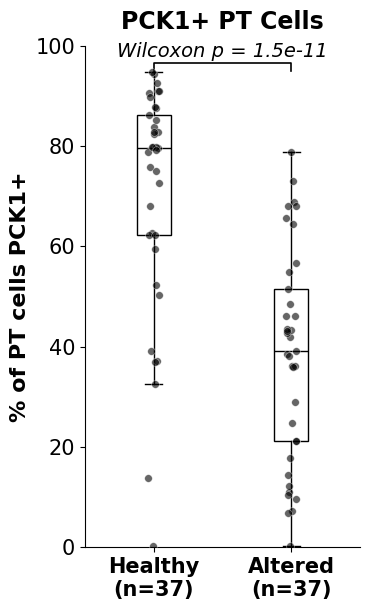

Saved results/figures/PCK1_control_percent.png
  healthy=70.24%, altered=38.22%, n=37 pairs; t p=4.6e-17; Wilcoxon p=1.46e-11; healthy>altered in 37/37

=== Q0: PT positivity, HRT vs CKD, per-sample test (SOX4 / SOX9 / double+) ===
  PT cells: 325,243
  SOX4      : HRT mean=1.59% (n=9)  CKD mean=10.47% (n=28)  per-sample Welch p=5.971e-06
  SOX9      : HRT mean=1.60% (n=9)  CKD mean=5.05% (n=28)  per-sample Welch p=5.766e-05
  SOX4&SOX9 : HRT mean=0.22% (n=9)  CKD mean=2.50% (n=28)  per-sample Welch p=1.612e-05


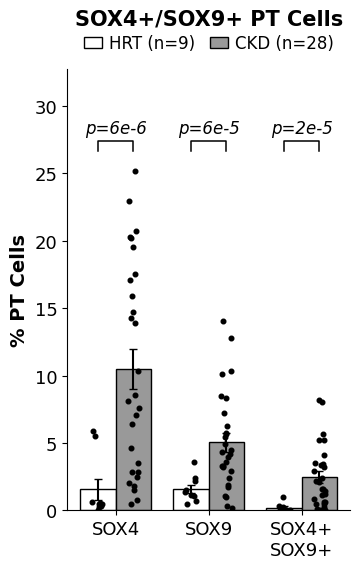

Saved results/figures/Q0_PT_SOX4_SOX9_HRTvsCKD.png

=== Q1: SOX4+ across ALL cells, HRT vs CKD ===
    percent SOX4+:  HRT n=9 mean=2.692   CKD n=28 mean=6.686   Welch p = 1.552e-05


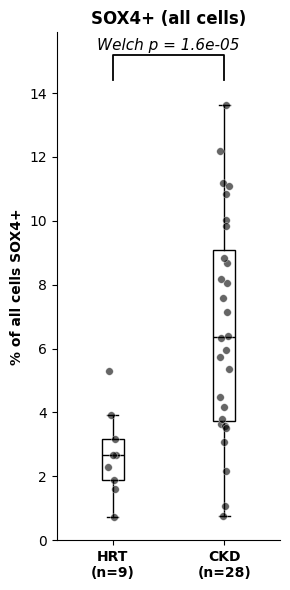

Saved results/figures/Q1_SOX4_allcells_percent.png
  HRT: n=9, mean=2.69, SEM=0.45
  CKD: n=28, mean=6.69, SEM=0.65
  Welch-test: p = 1.552e-05

=== Q3: SOX4+ across ALL tubular epithelium, HRT vs CKD ===
  tubular epithelial cells: 782,903 of 1,400,168
    percent SOX4+:  HRT n=9 mean=3.711   CKD n=28 mean=11.529   Welch p = 2.1e-06


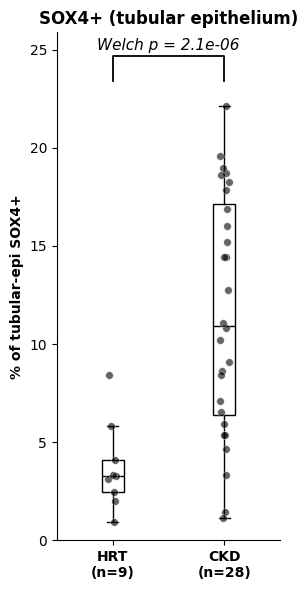

Saved results/figures/Q3_SOX4_tubular_percent.png
  HRT: n=9, mean=3.71, SEM=0.74
  CKD: n=28, mean=11.53, SEM=1.15
  Welch-test: p = 2.1e-06

=== Diagnostic: mean per-sample %SOX4+ by cell type (HRT vs CKD) ===
Category     Ref    CKD  CKD_minus_HRT
cell_type                             
aPT         5.10  31.47          26.37
DTL2       18.36  44.17          25.82
DTL3        7.54  28.97          21.43
frPT        6.87  27.40          20.53
DTL1       12.17  30.00          17.82
aTAL        8.36  25.74          17.38
aDTL        7.41  23.57          16.16
aDCT        5.62  21.05          15.43
angEC-PTC   1.31  14.35          13.04
frTAL       8.61  21.18          12.57
aCNT       14.30  26.85          12.55
dDTL       10.99  23.38          12.39
cycTAL      0.49  10.13           9.64
C-PC       11.23  19.51           8.28
PEC         3.26  10.88           7.62
M-TAL       4.28  11.78           7.51
EC-LYM      2.21   9.11           6.90
M-PC       12.06  18.85           6.79
IMCD    

In [32]:
per_sample = analyze(dfc_full)

pck1_stats, pck1_paired = plot_pck1_control(dfc_full)

q0_rows, q0_results = reproduce_pt_figure(dfc_full)
q1_summary, q1_p = q1_all_cells_sox4(dfc_full)
q3_summary, q3_p = q3_tubular_sox4(dfc_full)
by_celltype = sox4_by_celltype(dfc_full)

In [33]:
# sensitivity analysis without 4 added samples (to check if association still exists)

set_contrast(PRIMARY_CONTRAST)

df_main = df[df[COL_SAMPLE].map(SAMPLE_SITE) == "main"]
dfc_main = contrast_subset(df_main)

main_counts = (
    pd.Series({s: SAMPLE_CATEGORY.get(s) for s in dfc_main[COL_SAMPLE].unique()})
    .dropna().value_counts().to_dict()
)

if main_counts != EXPECTED["main_only"]:
    raise ValueError(f"Main-site-only: expected {EXPECTED['main_only']}, got {main_counts}")

LABEL_MAIN = (f"HRT (n={EXPECTED['main_only'][REF_LABEL]}) vs "
              f"CKD (n={EXPECTED['main_only'][CKD_LABEL]}) — main site only")

sensitivity, sensitivity_per_sample = results_table(
    dfc_main,
    contrast_label=LABEL_MAIN,
    summary_csv=TABLE_DIR / "results_summary_main_site_only.csv",
    per_sample_csv=TABLE_DIR / "results_per_sample_main_site_only.csv",
)

Contrast set: {'CKD': 28, 'Ref': 9}  (samples with other dx are ignored by HRT-vs-CKD tests)
Contrast subset: 33 samples kept {'CKD': 28, 'Ref': 9}; 0 unmapped dropped.
================  RESULTS  —  HRT (n=6) vs CKD (n=27) — main site only  ================
                                                  Endpoint                               comparison  grpA_mean_pct  grpB_mean_pct  fold  n_A  n_B                          test        p              direction
                        SOX4+ PT cells (% of PT) — PRIMARY HRT (n=6) vs CKD (n=27) — main site only          0.400         10.575  26.4    6   27              Welch per-sample 4.43e-07        increase in CKD
SOX4+ healthy PT only (PT-S1/2/3) — annotation-independent HRT (n=6) vs CKD (n=27) — main site only          0.077          3.694  48.2    6   27              Welch per-sample 4.84e-05        increase in CKD
         SOX4+SOX9+ PT cells (% of PT) — most conservative HRT (n=6) vs CKD (n=27) — main site only          0.097    

In [34]:
# side by side comparison

comparison = (
    primary[["Endpoint", "grpA_mean_pct", "grpB_mean_pct", "fold", "p"]]
    .merge(
        sensitivity[["Endpoint", "grpA_mean_pct", "grpB_mean_pct", "fold", "p"]],
        on="Endpoint", suffixes=("_both_sites", "_main_only"),
    )
)

comparison["same_direction"] = (
    np.sign(comparison["grpB_mean_pct_both_sites"] - comparison["grpA_mean_pct_both_sites"])
    == np.sign(comparison["grpB_mean_pct_main_only"] - comparison["grpA_mean_pct_main_only"])
)

comparison["both_p_lt_0.05"] = (comparison["p_both_sites"] < 0.05) & (comparison["p_main_only"] < 0.05)

comparison.to_csv(TABLE_DIR / "sensitivity_comparison.csv", index=False)

disp = comparison.copy()
for col in ("p_both_sites", "p_main_only"):
    disp[col] = disp[col].map(lambda x: f"{x:.2e}")

print(disp.to_string(index=False))
print(f"\nSaved {TABLE_DIR / 'sensitivity_comparison.csv'}")

                                                  Endpoint  grpA_mean_pct_both_sites  grpB_mean_pct_both_sites  fold_both_sites p_both_sites  grpA_mean_pct_main_only  grpB_mean_pct_main_only  fold_main_only p_main_only  same_direction  both_p_lt_0.05
                        SOX4+ PT cells (% of PT) — PRIMARY                     1.589                    10.469              6.6     5.97e-06                    0.400                   10.575            26.4    4.43e-07            True            True
SOX4+ healthy PT only (PT-S1/2/3) — annotation-independent                     0.563                     3.696              6.6     3.93e-04                    0.077                    3.694            48.2    4.84e-05            True            True
         SOX4+SOX9+ PT cells (% of PT) — most conservative                     0.217                     2.500             11.5     1.61e-05                    0.097                    2.533            26.2    1.05e-05            True            T

In [35]:
# crosstab

def cohort_provenance(group_map=None):
    if group_map is None:
        group_map = {"HRT": "HRT", "DKD": "CKD", "H-CKD": "CKD", "AKI": "AKI", "AKI-C": "AKI"}

    dx = pd.Series(SAMPLE_DX, name="dx")
    run = pd.Series({k: k.split("_")[0] for k in SAMPLE_DX}, name="run")
    site = pd.Series(SAMPLE_SITE, name="site")
    grp = dx.map(group_map).fillna("other")

    print(f"Unique participants (after de-dup): {len(dx)}\n")
    print("Per-diagnosis counts:\n" + dx.value_counts().to_string())
    print("\nAnalysis groups:\n" + grp.value_counts().to_string())
    print("\nGroup x site:\n" + pd.crosstab(site, grp).to_string())
    print("\nDx group x Xenium run (batch check):\n" + pd.crosstab(run, grp).to_string())

    hrt_runs = set(run[dx == "HRT"])
    ckd_runs = set(run[grp == "CKD"])

    print(f"\nHRT references span {len(hrt_runs)} independent runs: {sorted(hrt_runs)}")
    print(f"  -> {len(hrt_runs & ckd_runs)} also contain CKD: {sorted(hrt_runs & ckd_runs)}")

    table = pd.crosstab(run, grp)
    table.to_csv(TABLE_DIR / "cohort_run_by_group.csv")
    return table


batch_table = cohort_provenance()

Unique participants (after de-dup): 37

Per-diagnosis counts:
dx
DKD      19
H-CKD     9
HRT       9

Analysis groups:
dx
CKD    28
HRT     9

Group x site:
dx     CKD  HRT
site           
TISAC    1    3
main    27    6

Dx group x Xenium run (batch check):
dx      CKD  HRT
run             
TISAC     1    3
xen37     4    0
xen38     1    1
xen41     3    1
xen42     3    0
xen47     1    0
xen48     3    0
xen49     0    1
xen50     0    1
xen51     3    0
xen53     5    0
xen54     0    1
xen54B    1    0
xen55     2    0
xen56     0    1
xen59B    1    0

HRT references span 7 independent runs: ['TISAC', 'xen38', 'xen41', 'xen49', 'xen50', 'xen54', 'xen56']
  -> 3 also contain CKD: ['TISAC', 'xen38', 'xen41']


In [36]:
psm = pd.read_csv(TABLE_DIR / "results_per_sample_full.csv", index_col=0)
psm["run"] = [s.split("_")[0] for s in psm.index]
psm["batch"] = psm["run"].str.replace(r"[A-Z]$", "", regex=True)   # xen54B -> xen54

mixed = [b for b, g in psm.groupby("batch")
         if {REF_LABEL, CKD_LABEL} <= set(g["Category"])]

print(f"Batches containing both groups: {mixed}\n")

for b in mixed:
    g = psm[psm["batch"] == b]
    h = g.loc[g["Category"] == REF_LABEL, "SOX4_pct_PT"]
    c = g.loc[g["Category"] == CKD_LABEL, "SOX4_pct_PT"]
    flag = "CKD > HRT" if c.mean() > h.mean() else "** CKD <= HRT **"
    print(f"{b:<8} HRT n={len(h)} mean={h.mean():6.2f}   "
          f"CKD n={len(c)} mean={c.mean():6.2f}   {flag}")

sub = psm[psm["batch"].isin(mixed)]
print(f"\nWithin-batch subset: {len(sub)} samples")
print(sub.groupby("Category")["SOX4_pct_PT"].agg(["count", "mean", "sem"]).to_string())

Batches containing both groups: ['TISA', 'xen38', 'xen41', 'xen54']

TISA     HRT n=3 mean=  3.97   CKD n=1 mean=  7.61   CKD > HRT
xen38    HRT n=1 mean=  0.61   CKD n=1 mean= 22.92   CKD > HRT
xen41    HRT n=1 mean=  0.34   CKD n=3 mean=  9.04   CKD > HRT
xen54    HRT n=1 mean=  0.58   CKD n=1 mean= 20.27   CKD > HRT

Within-batch subset: 12 samples
          count       mean       sem
Category                            
CKD           6  12.986683  3.714901
Ref           6   2.239867  1.096054


In [37]:
# fig source data

def write_source_data(frame, name, note):
    """Write one figure's source data plus a note describing what the values are."""
    path = SOURCE_DATA_DIR / f"SourceData_{name}.csv"
    frame.to_csv(path, index=False)
    print(f"{len(frame):>5,} rows -> {path}")
    return {"file": path.name, "note": note}


notes = []

# Q0 — grouped bar, SOX4 / SOX9 / double-positive PT cells
notes.append(write_source_data(
    q0_rows,
    "Fig_Q0_PT_SOX4_SOX9",
    "Per-sample % of PT cells positive for each endpoint. pct = 100 * positive_cells / "
    "eligible_cells. Bars are arm means, error bars SEM, dots individual samples. "
    "Welch per-sample t-test.",
))

# PCK1 positive control — paired healthy vs altered PT
notes.append(write_source_data(
    pck1_paired,
    "Fig_PCK1_control",
    "Paired per-sample % PCK1+ within healthy PT and altered PT. Only samples "
    "contributing both states are included. Wilcoxon signed-rank, paired.",
))

# Q1 — SOX4 across all cells
notes.append(write_source_data(
    q1_summary,
    "Fig_Q1_SOX4_allcells",
    "Per-sample % of all cells SOX4+. Welch t-test, HRT vs CKD.",
))

# Q3 — SOX4 across tubular epithelium
notes.append(write_source_data(
    q3_summary,
    "Fig_Q3_SOX4_tubular",
    "Per-sample % of tubular epithelial cells SOX4+. Welch t-test, HRT vs CKD.",
))

# Diagnostic — SOX4 by cell type
notes.append(write_source_data(
    by_celltype.reset_index(),
    "Diagnostic_SOX4_by_celltype",
    "Mean per-sample %SOX4+ by cell type, restricted to sample/cell-type pairs with "
    "at least 50 cells. Not a figure panel; supports specificity of the PT signal.",
))

manifest_out = SOURCE_DATA_DIR / "SourceData_README.csv"
pd.DataFrame(notes).to_csv(manifest_out, index=False)
print(f"\nWrote {manifest_out}")

  111 rows -> results/source_data/SourceData_Fig_Q0_PT_SOX4_SOX9.csv
   37 rows -> results/source_data/SourceData_Fig_PCK1_control.csv
   37 rows -> results/source_data/SourceData_Fig_Q1_SOX4_allcells.csv
   37 rows -> results/source_data/SourceData_Fig_Q3_SOX4_tubular.csv
   86 rows -> results/source_data/SourceData_Diagnostic_SOX4_by_celltype.csv

Wrote results/source_data/SourceData_README.csv


In [39]:
if WRITE_CELL_TABLE:
    out_path = OBJECT_DIR / "cell_table_all_samples.parquet"
    export = df.copy()
    export["Category"] = export[COL_SAMPLE].map(SAMPLE_CATEGORY)
    export["Site"] = export[COL_SAMPLE].map(SAMPLE_SITE)
    export["dx"] = export[COL_SAMPLE].map(SAMPLE_DX)
    export.to_parquet(out_path, index=False)
    print(f"Wrote {out_path} ({len(export):,} cells)")
else:
    print("WRITE_CELL_TABLE is False; skipping per-cell export.")

Wrote results/objects/cell_table_all_samples.parquet (1,400,168 cells)


In [38]:
p = OBJECT_DIR / "cell_table_all_samples.parquet"

print("WRITE_CELL_TABLE :", WRITE_CELL_TABLE)
print("OBJECT_DIR       :", OBJECT_DIR.resolve())
print("file exists      :", p.exists())
print("objects/ contents:", [f.name for f in OBJECT_DIR.glob("*")])
print("source_data/     :", [f.name for f in SOURCE_DATA_DIR.glob("*")])

WRITE_CELL_TABLE : True
OBJECT_DIR       : /storage2/fs1/sanjayjain/Active/Stephanie/xenium/results/objects
file exists      : False
objects/ contents: ['IUsamples_resolvi_20filter_with_corrected_BANKSY_spatial.h5ad', 'WASHU_4biopsies_resolvi_20filter_with_corrected_BANKSY_spatial.h5ad']
source_data/     : ['SourceData_BANKSY_bubble_plot_v2.csv', 'SourceData_Fig_Q0_PT_SOX4_SOX9.csv', 'SourceData_Fig_PCK1_control.csv', 'SourceData_Diagnostic_SOX4_by_celltype.csv', 'SourceData_BANKSY_bubble_plot_v2.xlsx', 'SourceData_BANKSY_bubble_plot.csv', 'SourceData_Fig_Q3_SOX4_tubular.csv', 'SourceData_README.csv', 'SourceData_BANKSY_bubble_plot.xlsx', 'SourceData_Fig_Q1_SOX4_allcells.csv']
